<a href="https://colab.research.google.com/github/overgroove/samsung_lecture/blob/main/03_feature_eng_transform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Transform distribution**
- 결측치 처리 후 데이터는 어떠한 머신러닝 모델이든 학습이 가능한 상태
- 다만 각 변수 데이터의 특징은 반영하지 않은 기초적인 전처리만 수행
- 변수의 분포에 따라 머신러닝 모델이 데이터의 특징을 잘 학습할 수 있도록 데이터를 변환
- 일반적으로 continues distribution, categorical distribution에 따라 변환방법 다름
- 각 분포별 처리 방법을 학습

## **data loading**

In [1]:
# 필요모듈 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

pd.options.display.max_columns = 200
pd.options.display.max_rows = 200

In [64]:
# ames_housing_split.joblib 파일데이터 로딩
data = joblib.load('./data_dict.joblib')

In [65]:
# 각각의 데이터셋 할당
X_train, X_test, y_train, y_test = data['X_train'], data['X_test'], data['y_train'], data['y_test']

## **1. Continues distribution transform**
- continuous distribution(연속형분포)를 보이는 데이터의 경우 스케일 차이로 인한 문제 발생
- 머신러닝 모델의 작동방법 차이로 인하여 변수의 스케일 변환작업을 필요로 할 경우가 있음
- 특히 거리기반 알고리즘인 **클러스터링**과 선형방정식 기반 **회귀모델**의 경우 **스케일이 큰 변수가 주도적으로 모델성능에 영향을 줌, 반드시 변수간 스케일 조정이 필요**
- 트리베이스 모델은 스케일조정에 따른 성능 변화 미미
- 회귀모델링 이후 변수의 절대적 정량분석을 위한 방법으로도 좋음

In [66]:
# 수치형 변수 선택
num_c = X_train.select_dtypes([int, float]).columns
num_c

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold'],
      dtype='object')

In [10]:
# 수치형 변수 데이터 확인
X_train[num_c].head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
254,255,20,70.0,8400,5,6,1957,1957,0.0,922,0,392,1314,1314,0,0,1314,1,0,1,0,3,1,5,0,1957.0,1,294,250,0,0,0,0,0,0,6,2010
1066,1067,60,59.0,7837,6,7,1993,1994,0.0,0,0,799,799,799,772,0,1571,0,0,2,1,3,1,7,1,1993.0,2,380,0,40,0,0,0,0,0,5,2009
638,639,30,67.0,8777,5,7,1910,1950,0.0,0,0,796,796,796,0,0,796,0,0,1,0,2,1,4,0,2005.0,0,0,328,0,164,0,0,0,0,5,2008
799,800,50,60.0,7200,5,7,1937,1950,252.0,569,0,162,731,981,787,0,1768,1,0,1,1,3,1,7,2,1939.0,1,240,0,0,264,0,0,0,0,6,2007
380,381,50,50.0,5000,5,6,1924,1950,0.0,218,0,808,1026,1026,665,0,1691,0,0,2,0,3,1,6,1,1924.0,1,308,0,0,242,0,0,0,0,5,2010


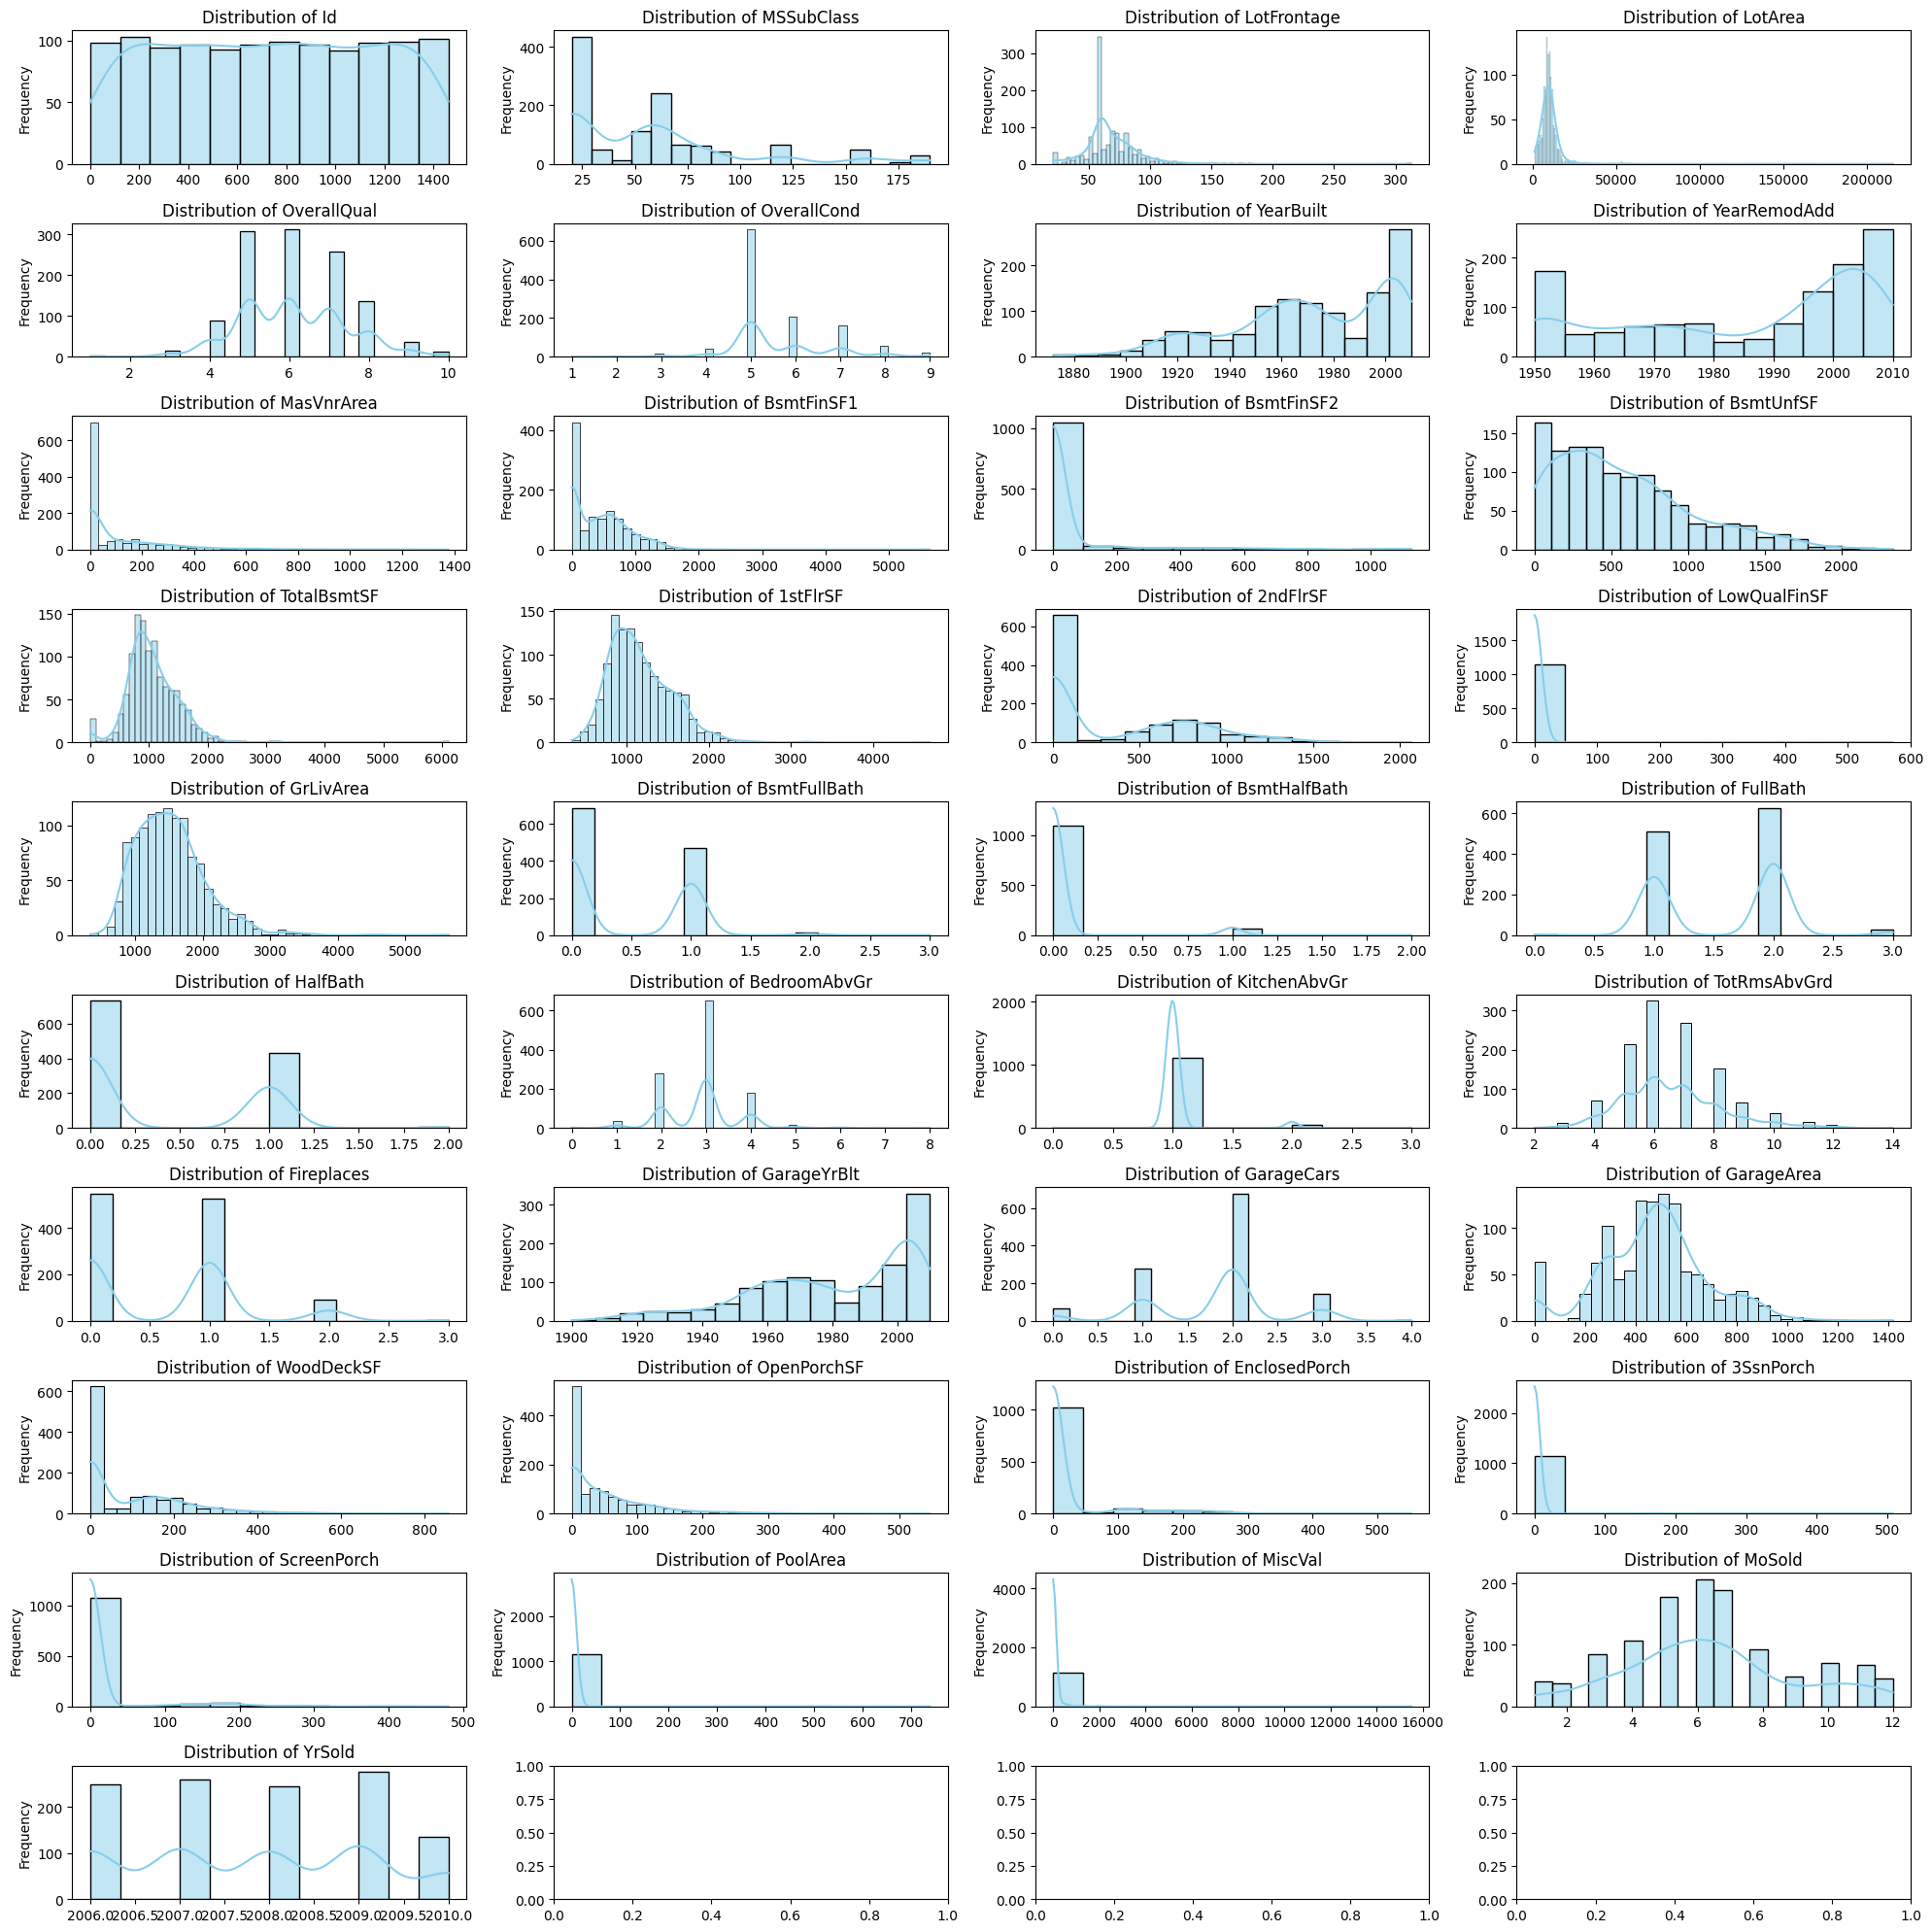

In [12]:
# 실수형 변수의 분포 확인
fig, axes = plt.subplots(nrows=10, ncols=4, figsize=(20, 20))
axes_flat = axes.ravel()
for i, col_name in enumerate(num_c):
    sns.histplot(data=X_train, x=col_name, ax=axes_flat[i], kde=True, color='skyblue')
    axes_flat[i].set_title(f'Distribution of {col_name}', fontsize=12)
    axes_flat[i].set_xlabel('') # Clear x-label to reduce clutter
    axes_flat[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show();

#### **1.1 StandardScaler(표준화)**
- 데이터의 평균을 0, 표준편차를 1로 변환하여 정규분포 형태로 만드는 기법
$$z = \frac{x - \mu}{\sigma}$$
($\mu$: 평균, $\sigma$: 표준편차)
- 데이터의 범위를 제한하지는 않지만, 대다수의 머신러닝 알고리즘(특히 선형 모델 및 신경망)의 기본
- 이상치(Outlier)가 존재할 경우 평균과 표준편차에 영향을 주어 스케일링 결과가 왜곡될 수 있음

#### **1.2 MinMaxScaler(정규화)**
- 데이터의 모든 값을 0과 1 사이의 범위로 변환
$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$
- 모든 특성의 스케일을 동일하게 맞추는 데 유용하며, 데이터의 하한과 상한이 명확할 때 효과적
- 이미지 처리나 k-NN처럼 거리 기반 알고리즘에 유용
- 이상치에 매우 민감. 아주 큰 이상치가 하나만 있어도 나머지 데이터들이 좁은 범위로 압축되어 정보가 손실

#### **1.3 RobustScaler**
- 평균과 표준편차 대신 **중앙값(Median)**과 **사분위수(IQR)**를 사용
$$x_{scaled} = \frac{x - Q_2}{Q_3 - Q_1}$$
($Q_1$: 1사분위수, $Q_2$: 중앙값, $Q_3$: 3사분위수)
- 이상치가 포함된 데이터를 다룰 때 가장 안전. 데이터의 변동성이 클 때 유용.
- 표준화에 비해 통계적 특성이 덜 강조될 수 있습니다.

#### **1.4 Log Transformation(로그변환)**
- 오른쪽으로 긴 꼬리를 가진(Right-skewed) 분포를 정규분포에 가깝게 모아줌. 값이 큰 데이터들 사이의 간격을 좁혀주어 이상치(Outlier)의 영향력을 물리적으로 축소  

$$y = \ln(1 + x)$$  
$$역변환(Inverse)$$ $$x = e^y - 1$$

- 변수 간의 곱셈 관계를 덧셈 관계로 변환(비선형 관계의 선형화)하여 선형 모델에 유효
- 데이터의 스케일이 너무 클 때(예: 국가 예산, 인구수 등) 발생하는 연산 오류 방지, 학습 속도 개선

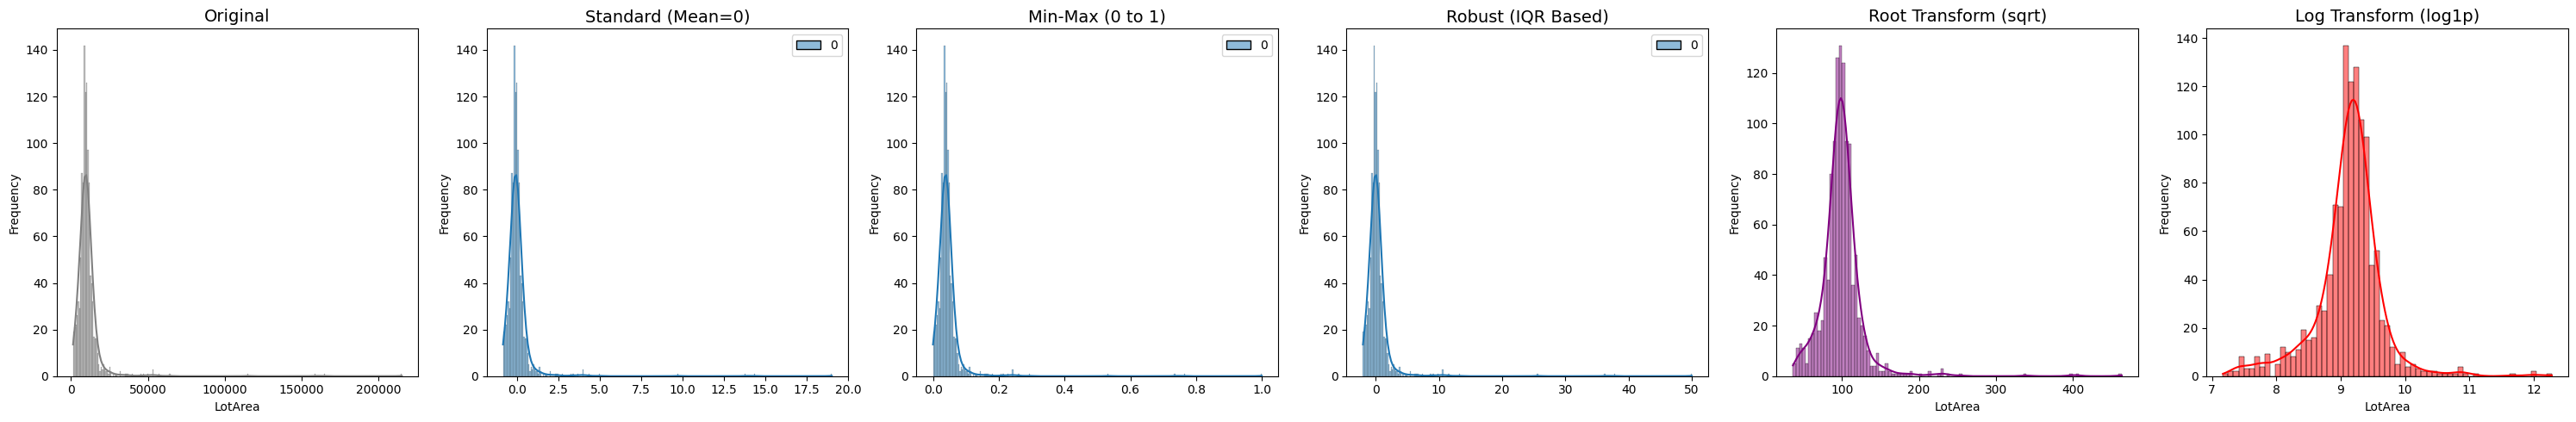

In [14]:
# 각 스케일링 방법에 따른 분포 변화 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

def visualize_scaling_comparison(df: pd.DataFrame, column: str) -> None:
    """
    Compare original distribution with 5 different scaling techniques in a (1, 6) grid:
    Original, Standard, Min-Max, Robust, Root, and Log1p.
    """
    # 1. Prepare Data (Handling 2D shape for Scikit-learn)
    data_to_scale = df[[column]].dropna()

    # 2. Initialize Scalers
    std_scaler = StandardScaler()
    mm_scaler = MinMaxScaler()
    rb_scaler = RobustScaler()

    # 3. Create Subplots: 1 row, 6 columns for Original + 5 transforms
    fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(30, 5))

    # --- [0] Original Distribution ---
    sns.histplot(df[column], kde=True, ax=axes[0], color='gray')
    axes[0].set_title('Original', fontsize=14)

    # --- [1] Standard Scaler ---
    std_data = std_scaler.fit_transform(data_to_scale)
    sns.histplot(std_data, kde=True, ax=axes[1], color='blue')
    axes[1].set_title('Standard (Mean=0)', fontsize=14)

    # --- [2] Min-Max Scaler ---
    mm_data = mm_scaler.fit_transform(data_to_scale)
    sns.histplot(mm_data, kde=True, ax=axes[2], color='green')
    axes[2].set_title('Min-Max (0 to 1)', fontsize=14)

    # --- [3] Robust Scaler ---
    rb_data = rb_scaler.fit_transform(data_to_scale)
    sns.histplot(rb_data, kde=True, ax=axes[3], color='orange')
    axes[3].set_title('Robust (IQR Based)', fontsize=14)

    # --- [4] Root Transformation (e.g., square root) ---
    # Ensure data is non-negative for root transformation
    root_data = np.sqrt(df[column].apply(lambda x: max(0, x)))
    sns.histplot(root_data, kde=True, ax=axes[4], color='purple')
    axes[4].set_title('Root Transform (sqrt)', fontsize=14)

    # --- [5] Log Transformation (log1p) ---
    log_data = np.log1p(df[column])
    sns.histplot(log_data, kde=True, ax=axes[5], color='red')
    axes[5].set_title('Log Transform (log1p)', fontsize=14)

    # Common labels and layout adjustment
    for ax in axes:
        ax.set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

visualize_scaling_comparison(X_train, 'LotArea')

In [77]:
# LotArea 스케일러 적용
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# 객체 할당
std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()
rb_scaler = RobustScaler()

std_scaler.fit(X_train[['LotArea']])
X_train[['LotArea_stded']] = std_scaler.transform(X_train[['LotArea']])
X_test[['LotArea_stded']] = std_scaler.transform(X_test[['LotArea']])

# log transform
X_train[['LotArea_log']] = np.log1p(X_train[['LotArea']])
X_test[['LotArea_log']] = np.log1p(X_test[['LotArea']])

In [68]:
# 로그 변환이 필요한 변수 선별 skew 1 기준 .skew()
# 숫자형 변수 내 skew()
num_skew_c = [cn for cn in num_c if X_train[cn].skew() > 1]
num_skew_c

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'TotalBsmtSF',
 '1stFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtHalfBath',
 'KitchenAbvGr',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal']

In [22]:
X_train[num_skew_c]

,MSSubClass,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,TotalBsmtSF,1stFlrSF,LowQualFinSF,GrLivArea,BsmtHalfBath,KitchenAbvGr,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal
254,20,70.0,8400,0.0,922,0,1314,1314,0,1314,0,1,250,0,0,0,0,0,0
1066,60,59.0,7837,0.0,0,0,799,799,0,1571,0,1,0,40,0,0,0,0,0
638,30,67.0,8777,0.0,0,0,796,796,0,796,0,1,328,0,164,0,0,0,0
799,50,60.0,7200,252.0,569,0,731,981,0,1768,0,1,0,0,264,0,0,0,0
380,50,50.0,5000,0.0,218,0,1026,1026,0,1691,0,1,0,0,242,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,20,78.0,9317,0.0,24,0,1314,1314,0,1314,0,1,0,22,0,0,0,0,0
1130,50,65.0,7804,0.0,622,0,1122,1328,0,1981,0,1,431,44,0,0,0,0,0
1294,20,60.0,8172,0.0,167,0,864,864,0,864,0,1,0,0,0,0,0,0,0
860,50,55.0,7642,0.0,0,0,912,912,0,1426,0,1,0,240,0,0,0,0,0


In [76]:
num_skew_c

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'TotalBsmtSF',
 '1stFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtHalfBath',
 'KitchenAbvGr',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal']

In [74]:
# 선별 변수 로그변환
# 원본데이터에 업데이트
X_train[num_skew_c] = np.log1p(X_train[num_skew_c])
X_test[num_skew_c] = np.log1p(X_test[num_skew_c])

## **2. Categorical distribution Transform**
- 수치형 데이터라 하더라도 증감의 의미를 갖는 rank가 필요없다면 데이터의 구분이 필요하다.
- 범주형데이터라 구분하는 cardinality(고윳값 갯수에 따른 판단)에 따라 카테고리컬 변수를 정의
- onehotencoding 방식을 사용하여 해당 변수를 변환한다.
<img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/51.jpg">

In [70]:
# 범주형 변수 선별
cat_c = X_train.select_dtypes('object').columns.to_list()
# 카디널리티에 따른 카테고리컬 변수 확인
cat_c_c = [cn for cn in cat_c if X_train[cn].nunique() < 20] # nunique 고윳값 갯수
len(cat_c), len(cat_c_c)

(43, 42)

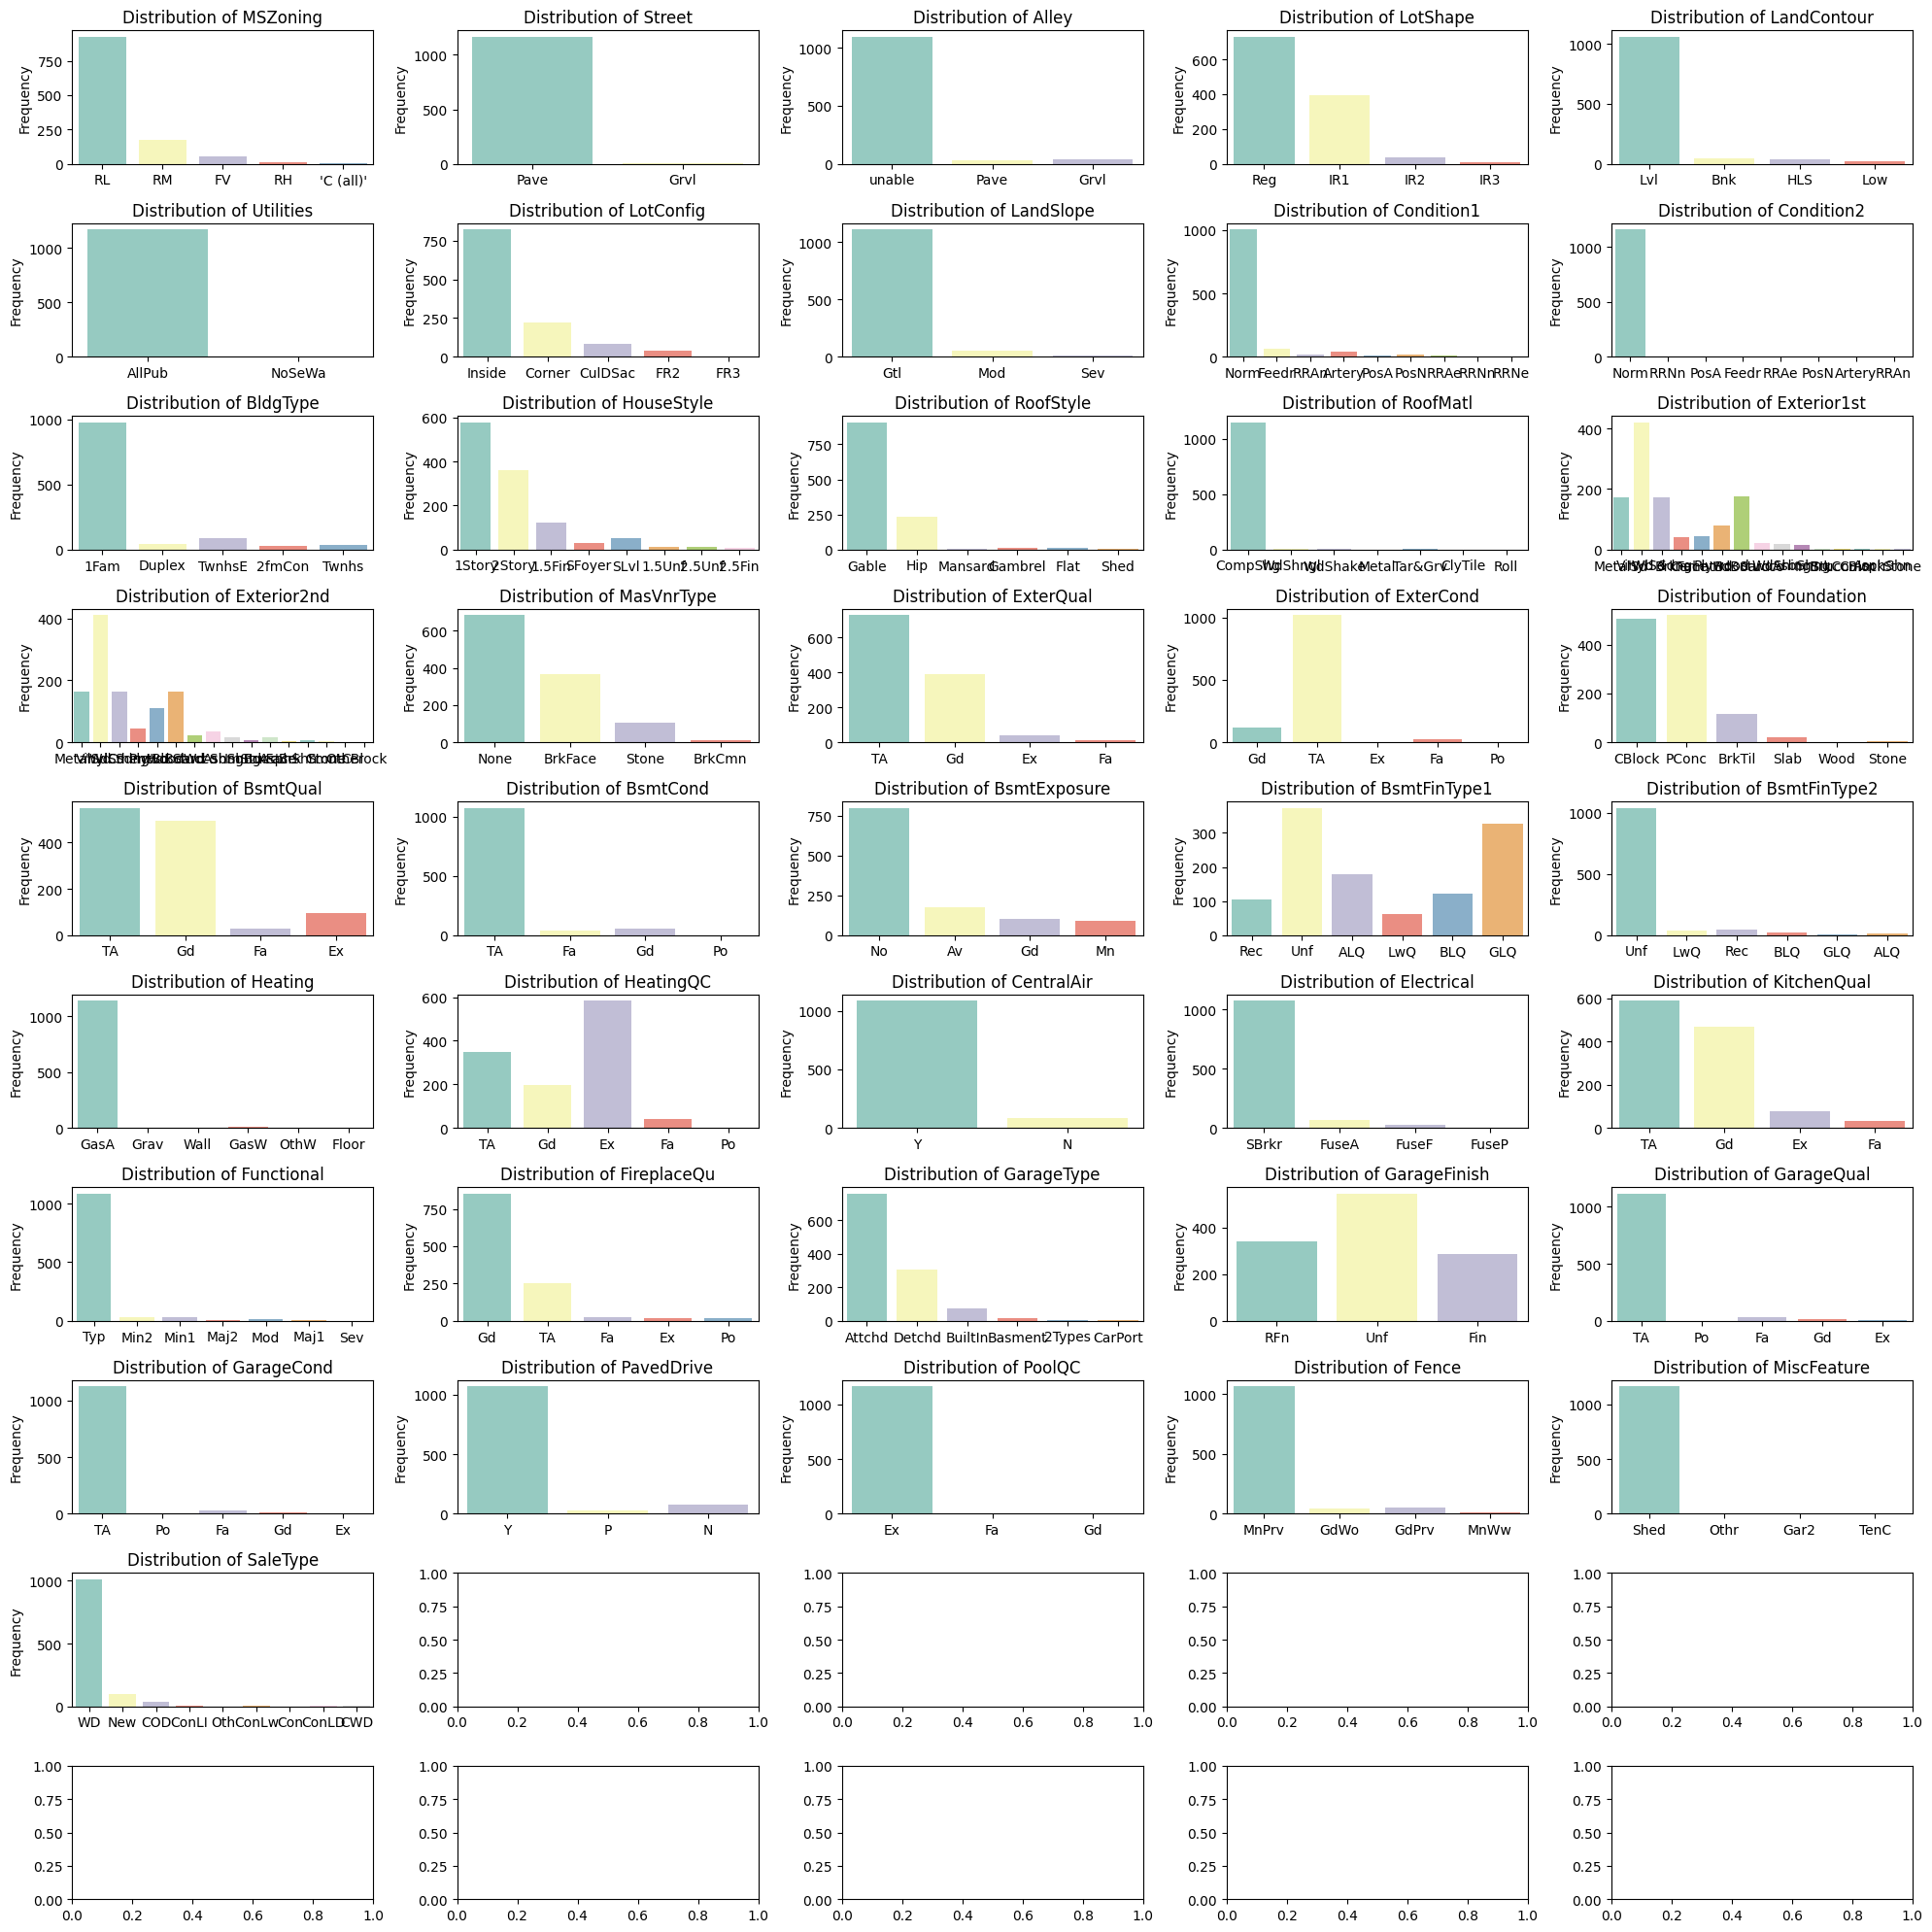

In [71]:
# 범주형 변수의 분포 확인
fig, axes = plt.subplots(nrows=10, ncols=5, figsize=(20, 20))

axes_flat = axes.ravel()

for i, col_name in enumerate(cat_c_c[:-1]):
    sns.countplot(data=X_train, x=col_name, ax=axes_flat[i], palette='Set3', legend=False, hue=col_name)
    axes_flat[i].set_title(f'Distribution of {col_name}', fontsize=12)
    axes_flat[i].set_xlabel('') # Clear x-label to reduce clutter
    axes_flat[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show();

### **2.2 Target encoding**
- 많은 카디널리티를 갖는 범주형 데이터를 처리하는 방법 중 하나  
- 변수 고윳값 기준 타겟데이터의 평균값을 변수값으로 치환하는 방법

In [36]:
cat_c_c

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [72]:
# 카디널리티 기준 구분이 필요한 범주형이지만 고윳값이 많은 경우 타겟 인코딩
# 'YrSold' 변수 고윳값 기준으로 타겟데이터의 평균값을 매칭
# 타겟데이터와 학습데이터 병합 이후에 groupby
target_mean = pd.concat([X_train[cat_c_c], y_train], axis=1).groupby('Exterior1st').mean(numeric_only=True)

# 타겟데이터 평균값을 기존 데이터의 고윳값에 매칭
X_train['Exterior1st_enc'] = X_train['Exterior1st'].map(target_mean['SalePrice'])
X_test['Exterior1st_enc'] = X_test['Exterior1st'].map(target_mean['SalePrice'])

# 테스트 데이터에 기존에 없던 카테고리가 들어온다면?

### **2.2 OneHotEncoding**
- onehotencoding의 장점은 데이터의 구분이 명확해지고 해당 패턴을 컴퓨터에게 학습 시킬 수 있는 점  
- 그에 따라 고윳값 갯수에 따라 늘어나는 설명변수의 갯수는 차원의 저주를 야기한다.  
- 변수 값에 0이 많은 경우 sparse한 데이터라 부르며 정보의 밀도가 낮아지며 변수가 많아짐에 따라 모델 복잡도에 따른 오버피팅 문제가 발생한다.  

In [57]:
# Onehotencoder 사용 단일 변수 적용
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first') # # 테스트 데이터에 기존에 없던 카테고리가 들어온다면?
ohe.fit(X_train[['MSZoning']])
ohe.transform(X_train[['MSZoning']])

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.]])

In [53]:
X_train['MSZoning'].unique()

array(['RL', 'RM', 'FV', 'RH', "'C (all)'"], dtype=object)

In [78]:
# sklearn.compose ColumnTransformer 활용 여러 변수에 한꺼번에 onehotencoding 적용
from sklearn.compose import ColumnTransformer

processing = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_c_c),
],
    remainder='passthrough'
)

processing.fit(X_train)
X_train_transformed = pd.DataFrame(processing.transform(X_train), columns=processing.get_feature_names_out())
X_test_transformed = pd.DataFrame(processing.transform(X_test), columns=processing.get_feature_names_out())
X_train_transformed

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [13, 28] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,onehot__MSZoning_FV,onehot__MSZoning_RH,onehot__MSZoning_RL,onehot__MSZoning_RM,onehot__Street_Pave,onehot__Alley_Pave,onehot__Alley_unable,onehot__LotShape_IR2,onehot__LotShape_IR3,onehot__LotShape_Reg,onehot__LandContour_HLS,onehot__LandContour_Low,onehot__LandContour_Lvl,onehot__Utilities_NoSeWa,onehot__LotConfig_CulDSac,onehot__LotConfig_FR2,onehot__LotConfig_FR3,onehot__LotConfig_Inside,onehot__LandSlope_Mod,onehot__LandSlope_Sev,onehot__Condition1_Feedr,onehot__Condition1_Norm,onehot__Condition1_PosA,onehot__Condition1_PosN,onehot__Condition1_RRAe,onehot__Condition1_RRAn,onehot__Condition1_RRNe,onehot__Condition1_RRNn,onehot__Condition2_Feedr,onehot__Condition2_Norm,onehot__Condition2_PosA,onehot__Condition2_PosN,onehot__Condition2_RRAe,onehot__Condition2_RRAn,onehot__Condition2_RRNn,onehot__BldgType_2fmCon,onehot__BldgType_Duplex,onehot__BldgType_Twnhs,onehot__BldgType_TwnhsE,onehot__HouseStyle_1.5Unf,onehot__HouseStyle_1Story,onehot__HouseStyle_2.5Fin,onehot__HouseStyle_2.5Unf,onehot__HouseStyle_2Story,onehot__HouseStyle_SFoyer,onehot__HouseStyle_SLvl,onehot__RoofStyle_Gable,onehot__RoofStyle_Gambrel,onehot__RoofStyle_Hip,onehot__RoofStyle_Mansard,onehot__RoofStyle_Shed,onehot__RoofMatl_CompShg,onehot__RoofMatl_Metal,onehot__RoofMatl_Roll,onehot__RoofMatl_Tar&Grv,onehot__RoofMatl_WdShake,onehot__RoofMatl_WdShngl,onehot__Exterior1st_AsbShng,onehot__Exterior1st_AsphShn,onehot__Exterior1st_BrkComm,onehot__Exterior1st_BrkFace,onehot__Exterior1st_CBlock,onehot__Exterior1st_CemntBd,onehot__Exterior1st_HdBoard,onehot__Exterior1st_ImStucc,onehot__Exterior1st_MetalSd,onehot__Exterior1st_Plywood,onehot__Exterior1st_Stone,onehot__Exterior1st_Stucco,onehot__Exterior1st_VinylSd,onehot__Exterior1st_WdShing,onehot__Exterior2nd_'Wd Sdng',onehot__Exterior2nd_'Wd Shng',onehot__Exterior2nd_AsbShng,onehot__Exterior2nd_AsphShn,onehot__Exterior2nd_BrkFace,onehot__Exterior2nd_CBlock,onehot__Exterior2nd_CmentBd,onehot__Exterior2nd_HdBoard,onehot__Exterior2nd_ImStucc,onehot__Exterior2nd_MetalSd,onehot__Exterior2nd_Other,onehot__Exterior2nd_Plywood,onehot__Exterior2nd_Stone,onehot__Exterior2nd_Stucco,onehot__Exterior2nd_VinylSd,onehot__MasVnrType_BrkFace,onehot__MasVnrType_None,onehot__MasVnrType_Stone,onehot__ExterQual_Fa,onehot__ExterQual_Gd,onehot__ExterQual_TA,onehot__ExterCond_Fa,onehot__ExterCond_Gd,onehot__ExterCond_Po,onehot__ExterCond_TA,onehot__Foundation_CBlock,onehot__Foundation_PConc,onehot__Foundation_Slab,onehot__Foundation_Stone,...,onehot__HeatingQC_Fa,onehot__HeatingQC_Gd,onehot__HeatingQC_Po,onehot__HeatingQC_TA,onehot__CentralAir_Y,onehot__Electrical_FuseF,onehot__Electrical_FuseP,onehot__Electrical_SBrkr,onehot__KitchenQual_Fa,onehot__KitchenQual_Gd,onehot__KitchenQual_TA,onehot__Functional_Maj2,onehot__Functional_Min1,onehot__Functional_Min2,onehot__Functional_Mod,onehot__Functional_Sev,onehot__Functional_Typ,onehot__FireplaceQu_Fa,onehot__FireplaceQu_Gd,onehot__FireplaceQu_Po,onehot__FireplaceQu_TA,onehot__GarageType_Attchd,onehot__GarageType_Basment,onehot__GarageType_BuiltIn,onehot__GarageType_CarPort,onehot__GarageType_Detchd,onehot__GarageFinish_RFn,onehot__GarageFinish_Unf,onehot__GarageQual_Fa,onehot__GarageQual_Gd,onehot__GarageQual_Po,onehot__GarageQual_TA,onehot__GarageCond_Fa,onehot__GarageCond_Gd,onehot__GarageCond_Po,onehot__GarageCond_TA,onehot__PavedDrive_P,onehot__PavedDrive_Y,onehot__PoolQC_Fa,onehot__PoolQC_Gd,onehot__Fence_GdWo,onehot__Fence_MnPrv,onehot__Fence_MnWw,onehot__MiscFeature_Othr,onehot__MiscFeature_Shed,onehot__MiscFeature_TenC,onehot__SaleType_CWD,onehot__SaleType_Con,onehot__SaleType_ConLD,onehot__SaleType_ConLI,onehot__SaleType_ConLw,onehot__SaleType_New,onehot__SaleType_Oth,onehot__SaleType_WD,onehot__SaleCondition_AdjLand,onehot__SaleCondition_Alloca,onehot__SaleCondition_Family,onehot__SaleCondition_Normal,onehot__SaleCondition_Partial,remainder__Id,remainder__MSSubClass,remainder__LotFrontage,remainder__LotArea,remainder__Neighborhood,remainder__OverallQual,remainder__OverallCond,rema

In [61]:
processing.get_feature_names_out()

array(['onehot__MSZoning_FV', 'onehot__MSZoning_RH',
       'onehot__MSZoning_RL', 'onehot__MSZoning_RM',
       'onehot__Street_Pave', 'onehot__Alley_Pave',
       'onehot__Alley_unable', 'onehot__LotShape_IR2',
       'onehot__LotShape_IR3', 'onehot__LotShape_Reg',
       'onehot__LandContour_HLS', 'onehot__LandContour_Low',
       'onehot__LandContour_Lvl', 'onehot__Utilities_NoSeWa',
       'onehot__LotConfig_CulDSac', 'onehot__LotConfig_FR2',
       'onehot__LotConfig_FR3', 'onehot__LotConfig_Inside',
       'onehot__LandSlope_Mod', 'onehot__LandSlope_Sev',
       'onehot__Condition1_Feedr', 'onehot__Condition1_Norm',
       'onehot__Condition1_PosA', 'onehot__Condition1_PosN',
       'onehot__Condition1_RRAe', 'onehot__Condition1_RRAn',
       'onehot__Condition1_RRNe', 'onehot__Condition1_RRNn',
       'onehot__Condition2_Feedr', 'onehot__Condition2_Norm',
       'onehot__Condition2_PosA', 'onehot__Condition2_PosN',
       'onehot__Condition2_RRAe', 'onehot__Condition2_RRAn',
  

In [79]:
import joblib
data_dict = {
    'X_train': X_train_transformed,
    'X_test': X_test_transformed,
    'y_train': y_train,
    'y_test': y_test
}

joblib.dump(data_dict, './1day.joblib')

['./1day.joblib']

### **3. Target log Transform**
- target데이터의 스케일 차이도 모델성능에 영향을 줄 수 있음
- 데이터의 분포가 넓은 영역에 존재하며(일반적으로 right-skew) 스케일 차이가 있다면 스케일링이 아닌 로그 변환을 수행
- 데이터의 단위가 아닌 상대적 비율에 초점을 맞추게 되며 이상치 영향 완화

In [ ]:
# 'SalePrice' 로그 변환 변수 생성


<Axes: xlabel='SalePrice_log', ylabel='Count'>

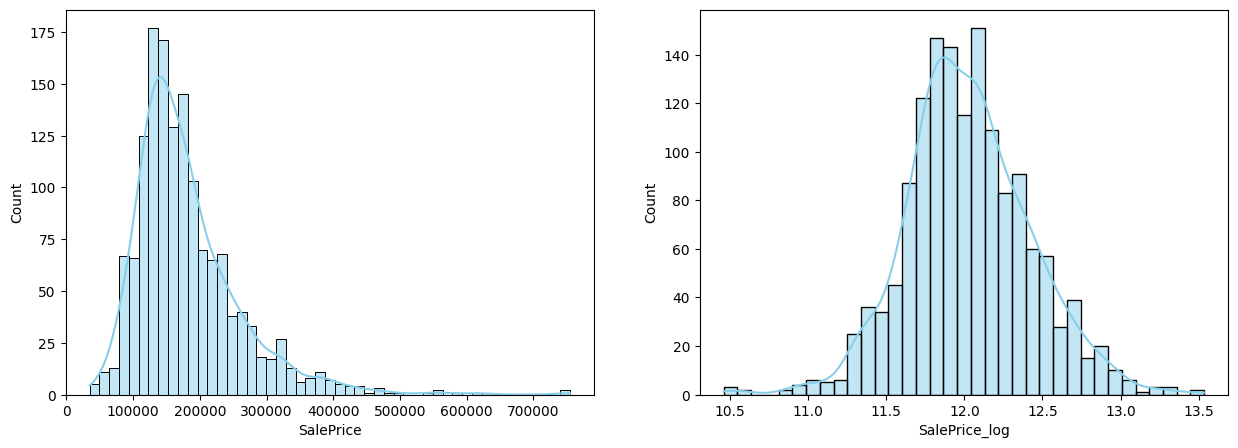

In [ ]:
# 타겟데이터 분포 로그변환 후 분포확인


In [ ]:
# 작업 데이터 저장


## **4. 전처리 Pipeline ColumnTransformer**

- 현재까지 적용한 missing value, transform의 기준에 따라 자동화 된 방식으로 전처리
- sklearn.compose ColumnTransformer를 사용하여 순차적 함수적용을 Pipeline으로 구성

In [ ]:
'''
수치형 변수에는 평균을 기준으로 결측처리, skew 1 기준으로 로그 변환과 스케일링을,
범주형 변수에는 최빈값을 기준으로 결측처리, 고윳값 갯수 10개준으로 원핫인코딩과 타겟 인코딩을 동시에 적용하는 복합 파이프라인
'''

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from xgboost import XGBRegressor

def build_complex_pipeline(df: pd.DataFrame, target_col: str) -> ColumnTransformer:
    """
    Builds a complex ColumnTransformer based on skewness and cardinality thresholds.
    """
    # 1. Feature Selection by Type
    numeric_features = df.select_dtypes(include=['number']).columns.tolist()
    if target_col in numeric_features: numeric_features.remove(target_col)
    categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

    # 2. Sub-grouping Numerical Features by Skewness (Threshold = 1.0)
    high_skew_features = [col for col in numeric_features if abs(df[col].skew()) > 1.0]
    low_skew_features = [col for col in numeric_features if abs(df[col].skew()) <= 1.0]

    # 3. Sub-grouping Categorical Features by Cardinality (Threshold = 30)
    high_card_features = [col for col in categorical_features if df[col].nunique() > 30]
    low_card_features = [col for col in categorical_features if df[col].nunique() <= 30]

    # --- Define Transformers ---

    # Numerical: Log + Scaling
    log_scaling_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('log', FunctionTransformer(np.log1p, validate=True, feature_names_out='one-to-one')),
        ('scaler', StandardScaler())
    ])

    # Numerical: Only Scaling
    scaling_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ])

    # Categorical: Target Encoding
    target_enc_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('target_enc', TargetEncoder())
    ])

    # Categorical: One-Hot Encoding
    onehot_enc_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    # 4. Final ColumnTransformer Integration
    preprocessor = ColumnTransformer(
        transformers=[
            ('num_high_skew', log_scaling_pipeline, high_skew_features),
            ('num_low_skew', scaling_pipeline, low_skew_features),
            ('cat_high_card', target_enc_pipeline, high_card_features),
            ('cat_low_card', onehot_enc_pipeline, low_card_features)
        ],
        remainder='passthrough'
    )

    return preprocessor

df = pd.read_csv('./ames_non_missing.csv')

y = df['SalePrice']
X = df.drop('SalePrice', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

preprocessor = build_complex_pipeline(X_train, 'SalePrice')
X_transformed = preprocessor.fit_transform(X_train, y_train)

X_train_transformed = pd.DataFrame(X_transformed, columns=preprocessor.get_feature_names_out())
X_test_transformed = pd.DataFrame(preprocessor.transform(X_test), columns=preprocessor.get_feature_names_out())

model = XGBRegressor(random_state=42)
pred = model.fit(X_train_transformed, y_train).predict(X_test_transformed)
print(f'RMSE: {root_mean_squared_error(y_test, pred)}')
print(f'R2: {r2_score(y_test, pred)}')

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


RMSE: 26100.43359375
R2: 0.9023755192756653


In [ ]:
# 위 작업으로 변환 된 데이터 확인


,num_high_skew__MSSubClass,num_high_skew__LotFrontage,num_high_skew__LotArea,num_high_skew__MasVnrArea,num_high_skew__BsmtFinSF1,num_high_skew__BsmtFinSF2,num_high_skew__TotalBsmtSF,num_high_skew__1stFlrSF,num_high_skew__LowQualFinSF,num_high_skew__GrLivArea,...,cat_low_card__SaleType_ConLw,cat_low_card__SaleType_New,cat_low_card__SaleType_Oth,cat_low_card__SaleType_WD,cat_low_card__SaleCondition_Abnorml,cat_low_card__SaleCondition_AdjLand,cat_low_card__SaleCondition_Alloca,cat_low_card__SaleCondition_Family,cat_low_card__SaleCondition_Normal,cat_low_card__SaleCondition_Partial
0,-1.121572,0.549809,0.247419,1.303490,-1.420419,-0.345185,0.368189,1.301065,-0.13634,0.453551,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.995932,-1.989945,-1.723115,0.821102,0.689403,-0.345185,-0.387725,-0.114095,-0.13634,-0.904483,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.421787,0.224124,-0.103809,-0.845461,-0.343515,-0.345185,-0.106255,-1.177818,-0.13634,0.201283,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-1.121572,0.700774,0.465688,1.321431,-1.420419,-0.345185,0.698197,1.692265,-0.13634,0.828959,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.421787,-1.361464,0.295441,-0.845461,0.572161,2.919419,-0.058123,-0.929013,-0.13634,0.415668,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,-1.121572,0.471508,0.039100,-0.845461,-0.343515,-0.345185,0.374839,0.525319,-0.13634,-0.290880,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1018,0.162645,-0.091587,-0.296592,-0.845461,0.732317,-0.345185,0.237337,0.558614,-0.13634,0.946925,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1019,-1.121572,-0.338321,-0.209305,-0.845461,0.293850,-0.345185,0.009932,-0.791570,-0.13634,-1.554610,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1020,0.162645,-0.606168,-0.336331,-0.845461,-1.420419,-0.345185,0.056981,-0.621776,-0.13634,-0.044274,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
